In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('mymoviedb.csv',lineterminator='\n')

In [ ]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [ ]:
#to check null value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [ ]:
#to check diff genre
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [ ]:
#to check duplicate value
df.duplicated().sum()


np.int64(0)

In [ ]:
#to check statisticsof the movie on vote count on vote count, vote avg for the popularity of the movie
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [ ]:
#to find which year has the most filmmed movies

df['Release_date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)


object


In [ ]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [ ]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Release_date
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021-12-15
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022-03-01
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022-02-25
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021-11-24
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021-12-22


In [ ]:
#taking imp things from column
cols = ['overview','Orignal_Language','Poster_Url']

In [ ]:
#taking imp things from column
cols = ['Overview','Original_Language','Poster_Url']
# dropping Columns
df.drop(cols,axis = 1, inplace = True )
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre', 'Release_date'],
      dtype='object')

In [ ]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",2021-12-15
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",2022-03-01
2,2022,No Exit,2618.087,122,6.3,Thriller,2022-02-25
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",2021-11-24
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",2021-12-22


In [ ]:
#categorization of 4 diff datetypes in populer, Average, below_average,not_good
# converting number data into labels

def catigorize_col(df,col,labels):
  edges = [df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max']]

  df[col] = pd.cut(df[col],edges,labels = labels)
  return df

In [ ]:
labels = ['not_popular','below_average','average','popular' ]
catigorize_col(df,'Vote_Average',labels)
df['Vote_Average'].unique()

['popular', 'below_average', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_average' < 'average' < 'popular']

In [ ]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021-12-15
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022-03-01
2,2022,No Exit,2618.087,122,below_average,Thriller,2022-02-25
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy",2021-11-24
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War",2021-12-22


In [ ]:
df['Vote_Average'].value_counts()

,count
Vote_Average,
not_popular,2467
popular,2450
average,2412
below_average,2398


In [ ]:
# remove not non poplular movies from suggetion

df.dropna(inplace = True)
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0
Release_date,0


In [ ]:
# splitting geners into a list and then explode dataframe to have only one genre per row each movie

df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021-12-15
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021-12-15
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021-12-15
3,2022,The Batman,3827.658,1151,popular,Crime,2022-03-01
4,2022,The Batman,3827.658,1151,popular,Mystery,2022-03-01


In [ ]:
# casting column inro category

df['Genre'] = df ['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Release_Date  25552 non-null  int32         
 1   Title         25552 non-null  object        
 2   Popularity    25552 non-null  float64       
 3   Vote_Count    25552 non-null  int64         
 4   Vote_Average  25552 non-null  category      
 5   Genre         25552 non-null  category      
 6   Release_date  25552 non-null  datetime64[ns]
dtypes: category(2), datetime64[ns](1), float64(1), int32(1), int64(1), object(1)
memory usage: 949.2+ KB


In [ ]:
df.nunique()

,0
Release_Date,100
Title,9415
Popularity,8088
Vote_Count,3265
Vote_Average,4
Genre,19
Release_date,5846


In [ ]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021-12-15
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021-12-15
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021-12-15
3,2022,The Batman,3827.658,1151,popular,Crime,2022-03-01
4,2022,The Batman,3827.658,1151,popular,Mystery,2022-03-01


**DATA** **VISUALIZATION**

In [ ]:
# for visualization
sns.set_style('whitegrid')

In [ ]:
# most frequntly used genre

df['Genre'].describe()



,Genre
count,25552
unique,19
top,Drama
freq,3715


most frequntly used genre


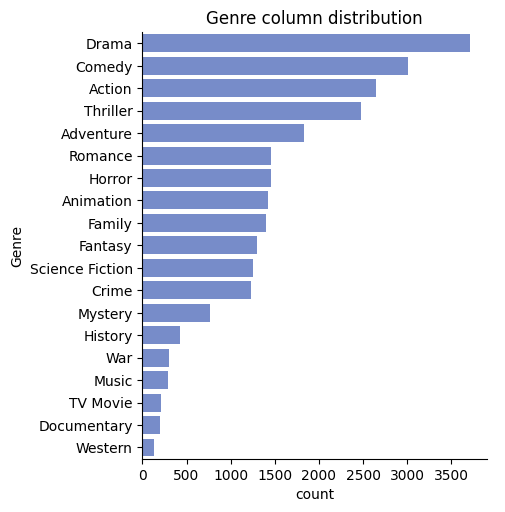

In [ ]:
# using seaborn lib to visualizse the data ,using catplot for showing categories

sns.catplot(y = 'Genre', data = df, kind ='count',
            order = df['Genre'].value_counts().index,
            color = '#6986d7' )
plt.title('Genre column distribution')
plt.show()

Highest vote for the vote column


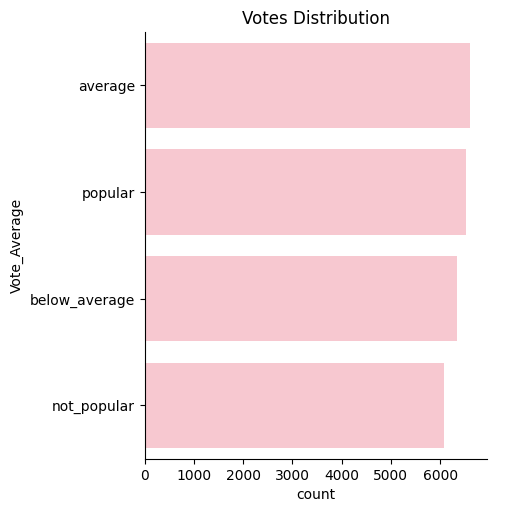

In [ ]:
sns.catplot ( y = 'Vote_Average', data= df , kind = 'count',
              order = df ['Vote_Average'].value_counts().index,
              color ='pink')

plt.title('Votes Distribution')
plt.show()

Highest popular Movie


In [ ]:
df[df['Popularity']== df ['Popularity'].max()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021-12-15
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021-12-15
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021-12-15


Non popular movie


In [ ]:
df[df['Popularity']== df ['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_date
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music,2021-03-31
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama,2021-03-31
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History,2021-03-31
25549,1984,Threads,13.354,186,popular,War,1984-09-23
25550,1984,Threads,13.354,186,popular,Drama,1984-09-23
25551,1984,Threads,13.354,186,popular,Science Fiction,1984-09-23


Which year has most filmed movies

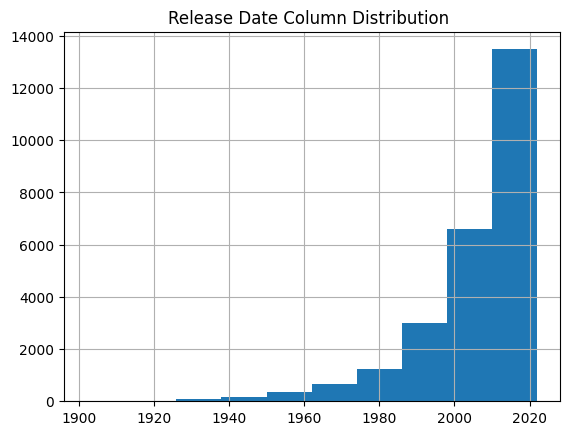

In [ ]:
df ['Release_Date'].hist()
plt.title('Release Date Column Distribution ')
plt.show()